In [8]:
import radiate as rd

rd.random.seed(67123)


In [9]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])


In [10]:
target_species = 4.0
rolling = int(target_species)

spec_count_signal = rd.metric("count.species").rolling(rolling).mean() / target_species
spec_dist_signal = (
    rd.metric("species.distance").mean().rolling(rolling).mean() / target_species
)
spec_thresh_signal = rd.metric("species.threshold").rolling(rolling).mean()
spec_evenness_signal = rd.metric("species.evenness").rolling(rolling).mean()

distance_signal = (
    (rd.lit(0.9) * spec_count_signal)
    + (rd.lit(0.4) * spec_dist_signal)
    + (rd.lit(0.2) * spec_thresh_signal)
    + (rd.lit(0.1) * spec_evenness_signal)
).clamp(0.01, 10.0)


# distance_signal.__repr__()


In [11]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), distance_signal)
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(
    log=True,
)


2026-04-13T14:38:49.207429Z  INFO Epoch 1    | Score:   2.9954 | Time: 325.67µs
2026-04-13T14:38:49.207638Z  INFO Epoch 2    | Score:   2.0038 | Time: 464.42µs
2026-04-13T14:38:49.207818Z  INFO Epoch 3    | Score:   2.0038 | Time: 585.83µs
2026-04-13T14:38:49.207998Z  INFO Epoch 4    | Score:   2.0038 | Time: 709.46µs
2026-04-13T14:38:49.208169Z  INFO Epoch 5    | Score:   2.0038 | Time: 826.29µs
2026-04-13T14:38:49.208348Z  INFO Epoch 6    | Score:   2.0038 | Time: 952.75µs
2026-04-13T14:38:49.208513Z  INFO Epoch 7    | Score:   2.0038 | Time: 1.06ms
2026-04-13T14:38:49.208701Z  INFO Epoch 8    | Score:   2.0038 | Time: 1.19ms
2026-04-13T14:38:49.208886Z  INFO Epoch 9    | Score:   2.0038 | Time: 1.32ms
2026-04-13T14:38:49.209050Z  INFO Epoch 10   | Score:   2.0038 | Time: 1.43ms
2026-04-13T14:38:49.209217Z  INFO Epoch 11   | Score:   2.0038 | Time: 1.55ms
2026-04-13T14:38:49.209386Z  INFO Epoch 12   | Score:   2.0038 | Time: 1.67ms
2026-04-13T14:38:49.209540Z  INFO Epoch 13   | Score

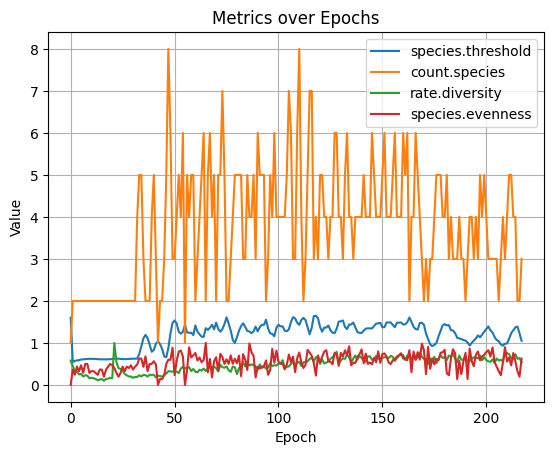

In [12]:
collector.plot(
    "species.threshold", "count.species", "rate.diversity", "species.evenness"
)
